In [83]:
import pandas as pd
import geopandas as gpd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import unicodedata
import libpysal
import networkx as nx
import re
from matplotlib import cm
from sklearn.manifold import MDS
from sklearn.metrics import pairwise_distances
from pathlib import Path

### Data Preparation

In [84]:
# Dataset preparation
# - remove thousand dots
# - replace decimal commas with dots
# - convert numeric-like strings to numbers; leave strings with letters/% as text
# - normalize province names in-place (overwrite 'prov')
# - hardcoded some provinces names for future merging 
# - save cleaned CSV


INPUT_FILE = "../data/ECEC_labour_2022 dataset.xlsx"  
SHEET = "Sheet1"
OUTDIR = Path("../data")

# Matches dots that are thousand separators: a dot between digits and followed by exactly 3 digits
_THOUSAND_DOT = re.compile(r"(?<=\d)\.(?=\d{3}(\D|$))")

def clean_number_string(x):
    
    if pd.isna(x):
        return x
    s = str(x).strip()
    if s == "":
        return s
    if re.search(r"[A-Za-z%]", s):
        return s.replace("\u00A0", "").strip()
    tampon=s.copy()
    s = _THOUSAND_DOT.sub("", s)
    s = s.replace("\u00A0", "").replace(" ", "")
    s = s.replace(",", ".")
    return s

def convert_object_numeric(df: pd.DataFrame, threshold: float = 0.7) -> pd.DataFrame:
    
    df = df.copy()
    num_pattern = re.compile(r"^-?\d+(\.\d+)?$")
    for c in df.columns:
        if df[c].dtype == "object":
            cleaned = df[c].map(clean_number_string)
            non_na = cleaned[~pd.isna(cleaned)]
            is_numlike = non_na.map(lambda v: bool(num_pattern.fullmatch(str(v))))
            ratio = (is_numlike.mean() if len(non_na) else 0.0)
            if ratio >= threshold:
                df[c] = pd.to_numeric(cleaned, errors="coerce")
            else:
                df[c] = cleaned
    return df

def norm(s):
    s = str(s).strip()
    s = unicodedata.normalize('NFKD', s).encode('ascii','ignore').decode('ascii')
    s = s.replace('-', ' ').replace('/', ' ').replace("'", '').replace('’','')
    s = ' '.join(s.split()).lower()
    return s


df = pd.read_excel(INPUT_FILE, sheet_name=SHEET)


df_clean = convert_object_numeric(df)

if 'prov' in df_clean.columns:
    df_clean['prov'] = df_clean['prov'].apply(norm)
    map = {
        'valle daosta vallee daoste': 'aosta',
        'reggio calabria': 'reggio di calabria',
        'bolzano bozen': 'bolzano',
    }
    df_clean['prov'] = df_clean['prov'].replace(map)

csv_path = OUTDIR / "cleaned_ECEC_labour_2022 dataset.csv"
df_clean.to_csv(csv_path, index=False, encoding="utf-8")

In [85]:
# Merging csv and geojson into a single file (still geojson to preserve geometry of provinces)

def norm(s):
    s = str(s).strip()
    s = unicodedata.normalize('NFKD', s).encode('ascii','ignore').decode('ascii')
    s = s.replace('-', ' ').replace('/', ' ').replace("'", '').replace('’','')
    s = ' '.join(s.split()).lower()
    return s

csv_path = "../data/cleaned_ECEC_labour_2022 dataset.csv"
df = pd.read_csv(csv_path)
df['join_key'] = df['prov'].apply(norm)


gjson_path = "../data/georef-italy-provincia.geojson"
gdf = gpd.read_file(gjson_path)



gdf['join_key'] = gdf['prov_name'].apply(norm)

manual_map = {
    'verbano cusio ossola': 'verbano cusio ossola',
    'valle daosta vallee daoste': 'valle daosta vallee daoste',
}
gdf['join_key'] = gdf['join_key'].replace(manual_map)

merged = gdf.merge(df, on='join_key', how='left')

unmatched = merged[merged['population'].isna()][['prov_name']]
print('Unmatched provinces:', unmatched.shape[0])
if unmatched.shape[0] > 0 :
    print(unmatched.head())


Unmatched provinces: 0


We can delete some non meaningfull columns

In [86]:
merged.drop(['join_key','year','rip_code','reg_code','prov_code', 'prov', 'prov_name_upper', 'prov_name_lower','prov_area_code', 'prov_type', 'prov_sigla'],axis=1,inplace=True)


out_path = "../data/merged_ecec_province.geojson"
merged.to_file(out_path, driver='GeoJSON')
print(merged.head())

                                        geo_point_2d  rip_name  \
0  { "lon": 8.7167073316998636, "lat": 39.9896141...     Isole   
1  { "lon": 10.892609586480846, "lat": 44.5367134...  Nord-Est   
2  { "lon": 16.490288659417445, "lat": 38.8960158...       Sud   
3  { "lon": 12.439732254650272, "lat": 43.9268471...  Nord-Est   
4  { "lon": 13.726553612797131, "lat": 42.6453251...       Sud   

         reg_name  prov_name  \
0        Sardegna   Oristano   
1  Emilia-Romagna     Modena   
2        Calabria  Catanzaro   
3  Emilia-Romagna     Rimini   
4         Abruzzo     Teramo   

                                            geometry  fem_empl_rate  \
0  MULTIPOLYGON (((8.27581 39.88234, 8.27496 39.8...           43.5   
1  MULTIPOLYGON (((10.48041 44.1895, 10.48183 44....           65.9   
2  POLYGON ((16.41984 38.55398, 16.42124 38.55287...           34.9   
3  POLYGON ((12.45062 44.16222, 12.44895 44.16278...           57.9   
4  POLYGON ((14.14626 42.53062, 14.14329 42.53276...   

### Data Exploration and Visualization

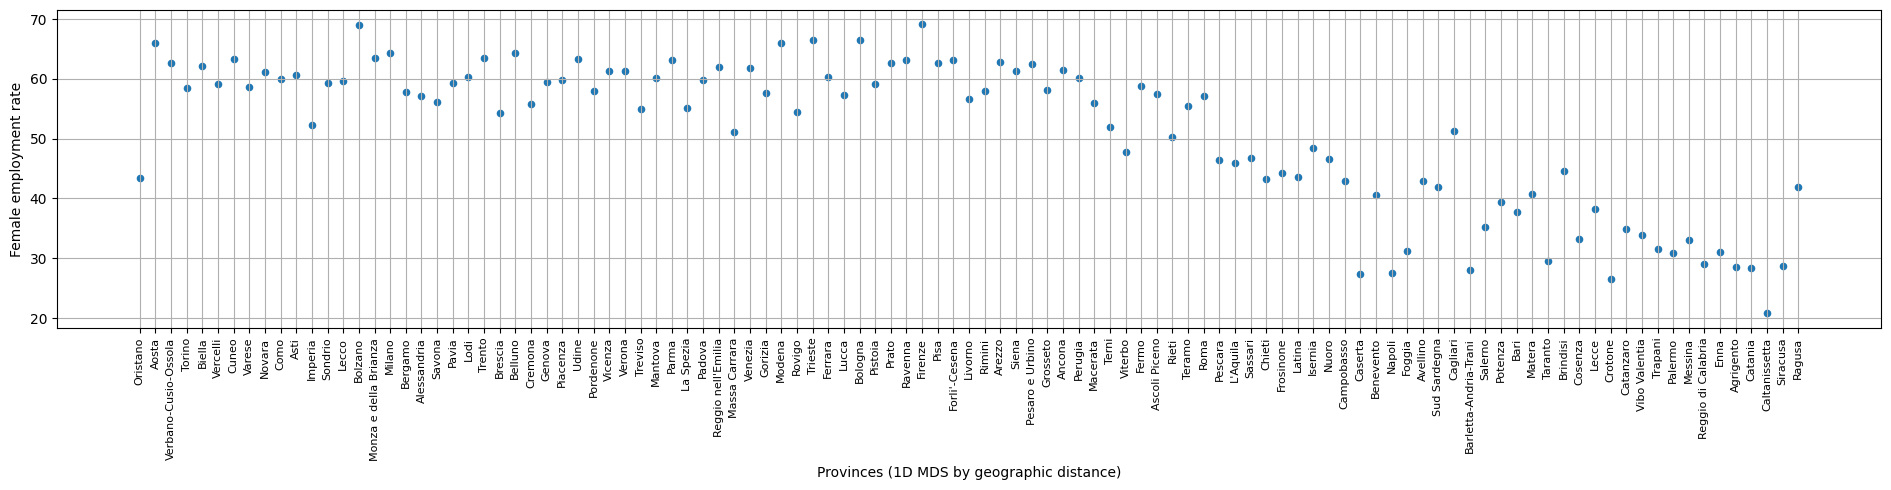

In [91]:
# Embed provinces on 1D
# Plot female employment rate

gdf = gpd.read_file(r"..\data\merged_ecec_province.geojson")

# Project to a metric CRS for Euclidean distances
centroids = gdf.to_crs(3857).geometry.centroid
coords = np.column_stack([centroids.x, centroids.y])

# 1D embedding via MDS on pairwise geographic distances
D = pairwise_distances(coords, metric="euclidean")
x1d = MDS(n_components=1, dissimilarity="precomputed", random_state=0).fit_transform(D).ravel()

# Order provinces by their 1D coordinate
order = np.argsort(x1d)
prov_names = gdf["prov_name"].to_numpy()[order]
y = pd.to_numeric(gdf["fem_empl_rate"]).to_numpy()[order]

x = np.arange(len(prov_names))
fig_width = max(12, 0.22 * len(prov_names))
fig, ax = plt.subplots(figsize=(fig_width, 6))

ax.scatter(x, y, s=20)
ax.set_ylabel("Female employment rate")
ax.set_xlabel("Provinces (1D MDS by geographic distance)")
ax.set_xticks(x)
ax.set_xticklabels(prov_names, rotation=90, ha="center")
ax.tick_params(axis="x", labelsize=8)
fig.subplots_adjust(bottom=0.35)
plt.grid(True)
plt.show()


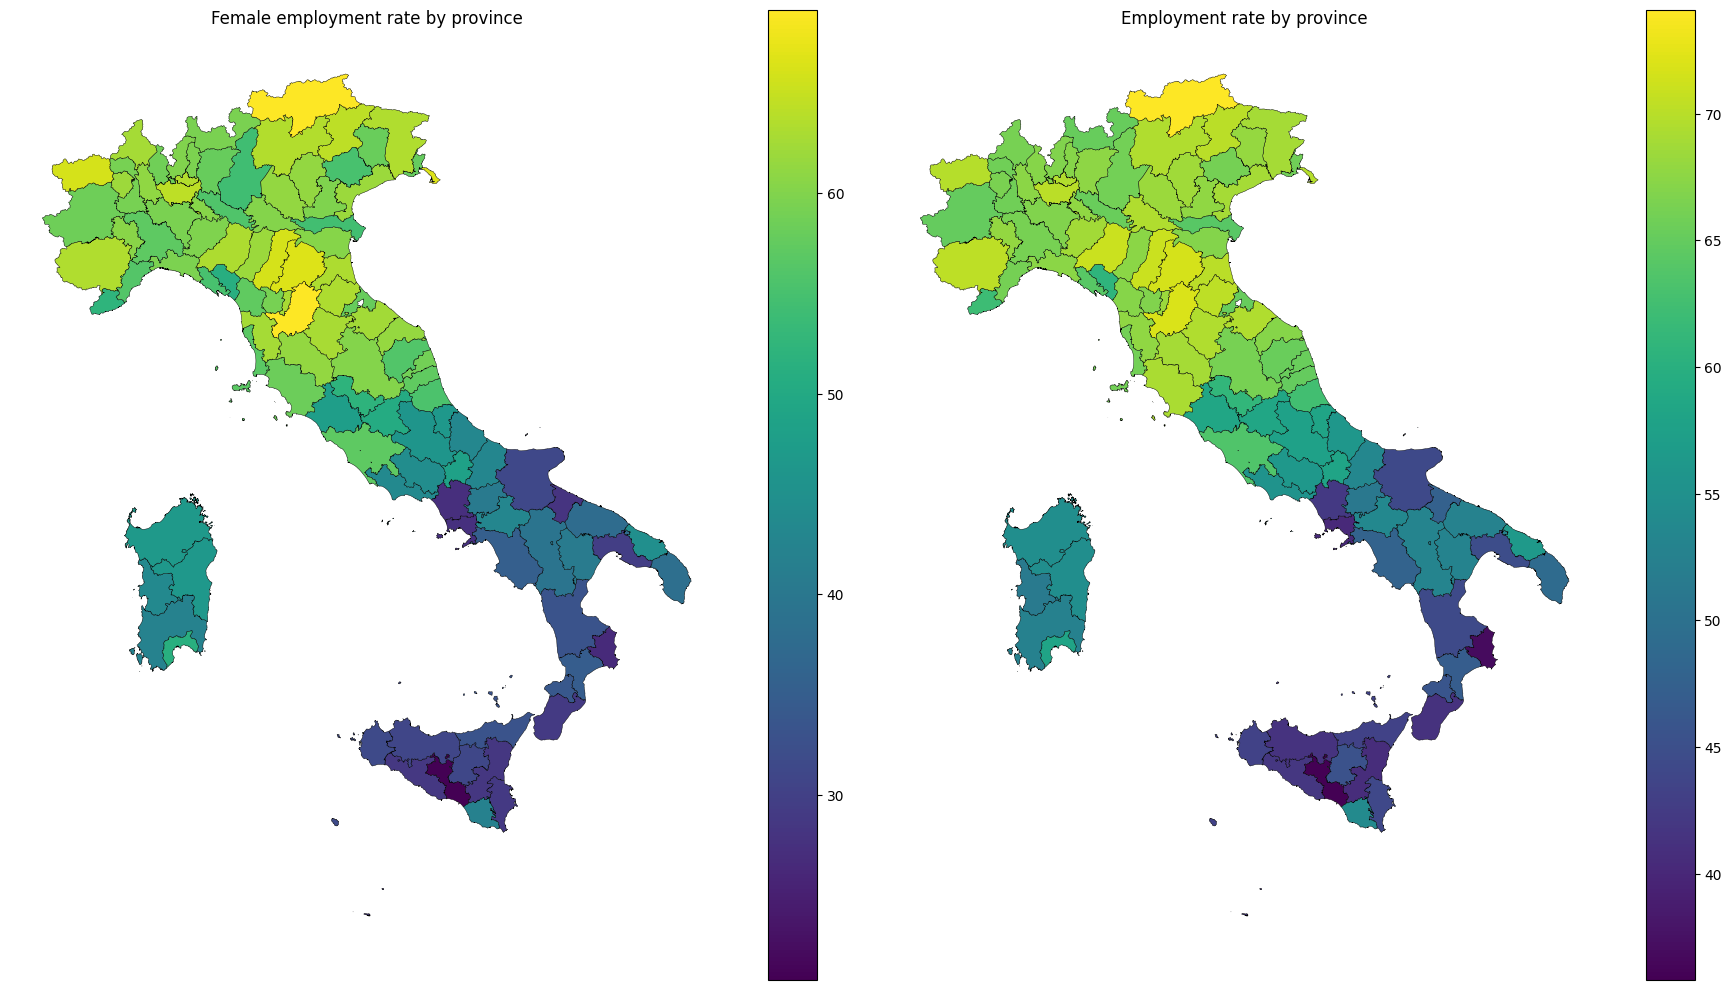

In [102]:
# Plot provinces and colour them based on female employment rate and we compare it with the global employement rate


fig, axs = plt.subplots(1, 2, figsize=(18, 10))

gdf.plot(
    column="fem_empl_rate",
    cmap="viridis",
    edgecolor="black",
    linewidth=0.3,
    ax=axs[0],
    figsize=(9, 10),
    legend=True,
    missing_kwds={"color": "lightgrey", "edgecolor": "white", "hatch": "///", "label": "No data"}
)

axs[0].set_title("Female employment rate by province")
axs[0].axis("off")

gdf.plot(
    column="empl_rate",
    cmap="viridis",  
    edgecolor="black",
    linewidth=0.3,
    legend=True,
    ax=axs[1],
    missing_kwds={
        "color": "lightgrey",
        "edgecolor": "white",
        "hatch": "///",
        "label": "No data"
    }
)
axs[1].set_title("Employment rate by province")
axs[1].axis("off")

plt.tight_layout()
plt.show()




Let's focus on the differences between the global employement rate and the female employement rate

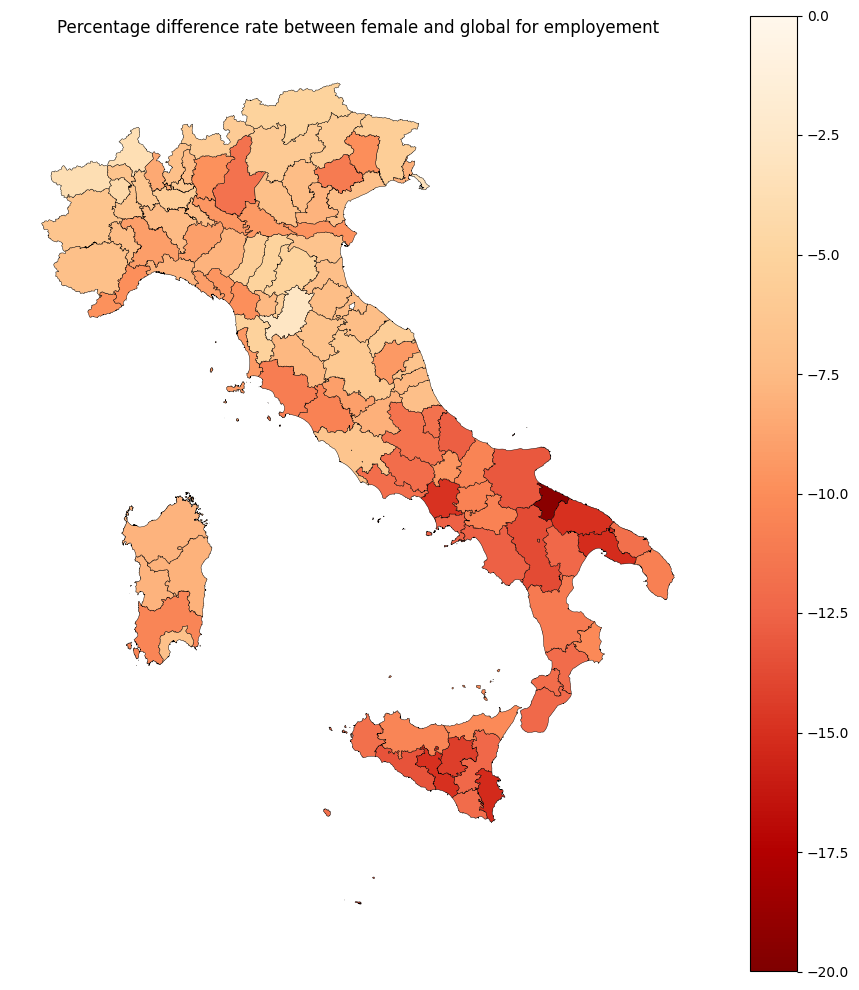

maximal value : -2.8
minimal value : -19.4


In [164]:
gdf_copy=gdf.copy()

gdf_copy["diff_empl_female_vs_glob"]=gdf["fem_empl_rate"]-gdf["empl_rate"]

vmin=round(min(gdf_copy["diff_empl_female_vs_glob"]),2)
vmax=round(max(gdf_copy["diff_empl_female_vs_glob"]),2)


ax = gdf_copy.plot(
    column="diff_empl_female_vs_glob",
    cmap="OrRd_r",
    edgecolor="black",
    vmin=-20,
    vmax=0,
    linewidth=0.3,
    figsize=(9, 10),
    legend=True,
    missing_kwds={"color": "lightgrey", "edgecolor": "white", "hatch": "///", "label": "No data"}
)




plt.title("Percentage difference rate between female and global for employement")
plt.axis("off")
plt.tight_layout()
plt.show()
print("maximal value :",vmax)
print("minimal value :",vmin)

Let's visualize the distribution of the difference

/var/folders/y9/rry2kyrd4wlb4xwqx57mrs540000gn/T/ipykernel_11853/3903467805.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


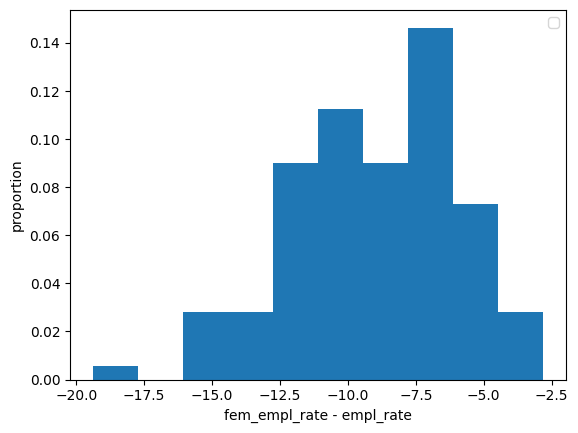

third quartile :  -6.950000000000003


In [166]:

plt.hist(gdf_copy["diff_empl_female_vs_glob"],density=True)

plt.xlabel("fem_empl_rate - empl_rate")
plt.ylabel("proportion")
plt.legend()
plt.show()

third_quartile=gdf_copy["diff_empl_female_vs_glob"].quantile(q=0.75)

print("third quartile : ",third_quartile)


Let's split the data into 2 groups : 
- fem_empl_rate - empl_rate < -6.95 (provinces with big difference)
- fem_empl_rate - empl_rate > -6.95 (provinces without big difference)

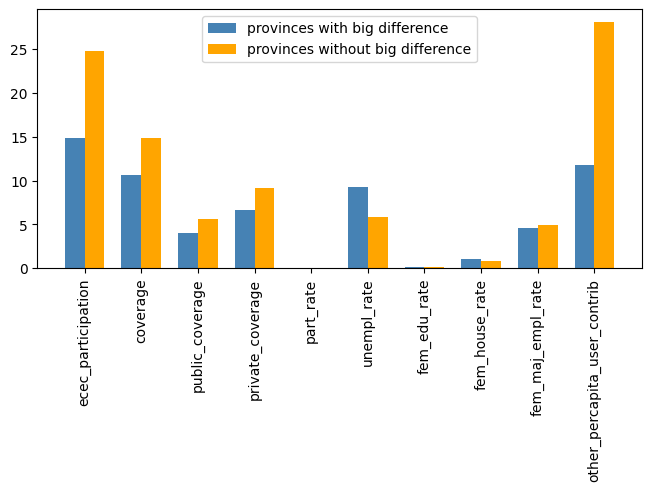

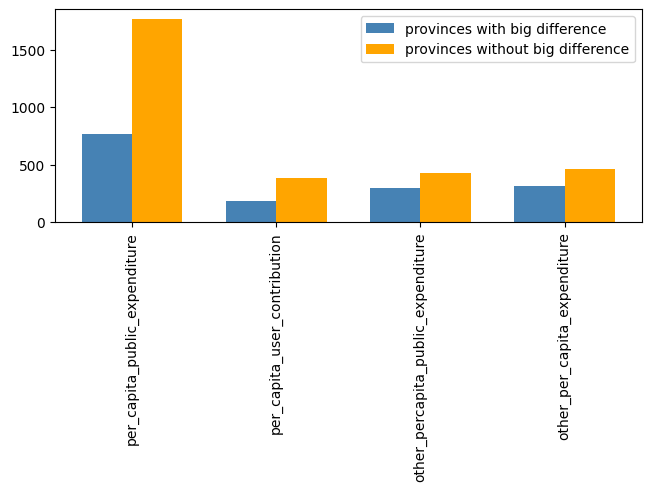

In [214]:
gdf_copy["big_difference_male_vs_female"]=0
gdf_copy.loc[ gdf_copy["diff_empl_female_vs_glob"]<third_quartile ,"big_difference_male_vs_female"]=1

scale1_var=[
    "ecec_participation", "coverage",
    "public_coverage", "private_coverage",
    "part_rate", "unempl_rate",
    "fem_edu_rate", "fem_house_rate", "fem_maj_empl_rate","other_percapita_user_contrib"

]

scale2_var=[ "per_capita_public_expenditure", "per_capita_user_contribution",  "other_percapita_public_expenditure","other_per_capita_expenditure"]


mean_list_1=gdf_copy.loc[gdf_copy["big_difference_male_vs_female"]==1,scale1_var].mean(axis=0)
mean_list_0=gdf_copy.loc[gdf_copy["big_difference_male_vs_female"]==0,scale1_var].mean(axis=0)

fig, ax = plt.subplots(layout='constrained')

x = np.arange(len(scale1_var))
width = 0.35  

ax.bar(x, mean_list_1, width, label='provinces with big difference', color='steelblue')
ax.bar(x+width, mean_list_0, width, label='provinces without big difference', color='orange')

ax.set_xticks(x+width/2, scale1_var)
ax.tick_params(axis='x', rotation=90)
ax.legend(loc='upper left', ncols=3)
plt.legend()
plt.show()


fig, ax = plt.subplots(layout='constrained')
x = np.arange(len(scale2_var))

mean_list_1=gdf_copy.loc[gdf_copy["big_difference_male_vs_female"]==1,scale2_var].mean(axis=0)
mean_list_0=gdf_copy.loc[gdf_copy["big_difference_male_vs_female"]==0,scale2_var].mean(axis=0)

ax.bar(x, mean_list_1, width, label='provinces with big difference', color='steelblue')
ax.bar(x+width, mean_list_0, width, label='provinces without big difference', color='orange')

ax.set_xticks(x+width/2, scale2_var)
ax.tick_params(axis='x', rotation=90)
ax.legend(loc='upper left', ncols=3)
plt.legend()
plt.show()


We note that the provinces without big differences have significantly bigger ecec_participation, coverage, other_percapita_user_contrib and per_capita_public_expenditure than the group with big differences. The question is : Are these different caracteristics the consequences or the causes of female_empl_rate ?

### Studying Correlation

In [ ]:
# Plotting correletaion matrix

df = pd.read_csv("../data/cleaned_ECEC_labour_2022 dataset.csv")

print("test3")
corr = df.drop(columns=['prov']).corr(method='pearson')

plt.figure(figsize=(38,42))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=True)
plt.title("Correlation Matrix of ECEC Labour Dataset")
plt.show()


NameError: name 'pd' is not defined